In [3]:
from decord import VideoReader
from decord import cpu, gpu
video_path = '/data2/local_datasets/ActivityNet/videos/v_mPtCJg-j4SM.mp4'
vr = VideoReader(video_path, ctx=cpu(0))

print('video frames:', len(vr))
# 1. the simplest way is to directly access frames
all_index = [1, 504, 625, 919, 1204, 1431, 1862, 2036, 2138, 2542, 2824, 3130, 3414, 3624, 3823,4245]
frames2 = vr.get_batch(all_index).asnumpy()
# frames2 = vr.get_batch(range(len(vr))).asnumpy()

# del frames2

video frames: 4594


In [1]:
vr.get_avg_fps()


NameError: name 'vr' is not defined

In [1]:
import av

video_path = '/data2/local_datasets/ActivityNet/videos/v_mPtCJg-j4SM.mp4'
container = av.open(video_path)

# 비디오 스트림을 선택합니다
video_stream = container.streams.video[0]

# 전체 프레임 수를 구하기 위해 duration과 time_base를 활용합니다.
num_frames = int(video_stream.duration * video_stream.time_base.denominator / video_stream.time_base.numerator)
print('video frames:', num_frames)

all_index = [1, 504, 625, 919, 1204, 1431, 1862, 2036, 2138, 2542, 2824, 3130, 3414, 3624, 3823, 4245]
frames2 = []

# 프레임을 가져옵니다
for i, frame in enumerate(container.decode(video_stream)):
    if i in all_index:
        frames2.append(frame.to_image())

container.close()


video frames: 1552025430000


KeyboardInterrupt: 

1405

In [12]:
import av

video_path = '/data2/local_datasets/ActivityNet/videos/v_6gzU9P-5tqE.mkv'
# video_path = '/data2/local_datasets/ActivityNet/videos/v__tRAypMWUdc.webm'
for video_path in non_mp4_files:
    container = av.open(os.path.join('/data2/local_datasets/ActivityNet/videos',video_path))
    video_stream = container.streams.video[0]
    if int(float(container.duration) / av.time_base * video_stream.base_rate) == 0:
        print(video_path)

In [6]:
import os
# v_G4kjV4ulJzo
# 현재 디렉터리의 파일과 폴더 목록을 가져옵니다.
files_in_directory = os.listdir('/data2/local_datasets/ActivityNet/videos')

# .mp4 확장자가 아닌 파일만 필터링합니다.
non_mp4_files = [file for file in files_in_directory if not file.endswith('.mp4')]

print(non_mp4_files)

['v_0CTnYEE7rdo.mkv', 'v_0gkxTQGR6zI.mkv', 'v_0hWGSkDnRHA.mkv', 'v_0ivHmKR8cUw.mkv', 'v_0RUMAGGab1k.mkv', 'v__0sDAdyMtnk.mkv', 'v_18QVPZgjy8w.mkv', 'v_1izVZnE0l7k.mkv', 'v_1oyWMusaDTI.mkv', 'v_1VmqefkNV_8.mkv', 'v_1Y1pKGFm-pQ.mkv', 'v_1zyyumIi0iQ.mkv', 'v_2hgXJR5QdkU.mkv', 'v_2mI7NL54yP8.mkv', 'v_2PAVJbmj2lQ.mkv', 'v_2QO41PbOUJ0.mkv', 'v_2_Tgrk8iJpE.mkv', 'v_2vOBrR0jKgY.mkv', 'v_2w3FSD235TY.mkv', 'v_2zwUExKXw9s.mkv', 'v_306mYrvdzIk.mkv', 'v_37Q3so6ERxs.mkv', 'v_3am00ii0n-o.mkv', 'v_3EuY86B4uTo.mkv', 'v_3j4OdbgaoAM.mkv', 'v_3LrLgh2rlAM.mkv', 'v_3MqnXsnEAkM.mkv', 'v_3XUxm78gjJE.mkv', 'v_3zPoB-_JxEc.mkv', 'v_45WfFPM5yvw.mkv', 'v_4gEDonpfTeY.mkv', 'v_4QqoWbK2ELc.mkv', 'v_4S5ethZhgqs.mkv', 'v_54K2F3zAZ0o.mkv', 'v_55bimE5eU9E.mkv', 'v_5bZ2FdbAKiQ.mkv', 'v_5E42nKwv1xY.mkv', 'v_5HW6mjZZvtY.mkv', 'v_5IkU9svJFRI.mkv', 'v_5MnHirHxqkA.mkv', 'v_5qh_gx81Bd8.mkv', 'v_5rtrGkZNfLo.mkv', 'v_5sl-E-AwptI.mkv', 'v_5t_hQVg9NsE.mkv', 'v_68kccxCgbys.mkv', 'v_6eQuZddoEcI.mkv', 'v_6GGQUpJR5qs.mkv', 'v_6Lh3yNFvs

In [5]:
import av

def load_from_file(
    filename,
    any_frame=False,
    backward=True
):

    container = av.open(filename)
    stream = container.streams.video[0]  # 1つ目のvideo stream．普通は1つしかないからこれでOK

    print("filename:", container.name)
    # print("filesize [bytes]:", container.size)
    print("filesize [kB]:", container.size // 1024)
    if container.size > 1024 * 1024:
        print("filesize [MB]:", container.size // 1024 // 1024)
    # print("bit_rate [b/s]:", container.bit_rate)
    print("bit_rate [kb/s]:", float(container.bit_rate) / 1024)
    print("container duration [sec]:",
          float(container.duration) / av.time_base)
    print("stream duration:", stream.duration)  # 謎
    print("frames:", stream.frames)
    print("guessed frames:",
          int(float(container.duration) / av.time_base * stream.base_rate))
    print("container format name:", container.format.name)
    print("container format long name:", container.format.long_name)
    print("codec name:", stream.codec_context.codec.name)
    print("codec long name:", stream.codec_context.codec.long_name)
    print("codec tag:", stream.codec_context.codec_tag)
    for md_str in container.metadata.keys():
        print(f"container metadata {md_str}:", container.metadata[md_str])
    print("base_rate [fps]:", stream.base_rate)
    print("rate [fps]:", stream.codec_context.rate)
    print("width [pix]:", stream.codec_context.width)
    print("height [pix]:", stream.codec_context.height)

    sec = 2  # 2秒時点へシーク
    container.seek(
        offset=sec // stream.time_base,
        any_frame=any_frame,
        backward=backward,
        stream=stream)

    for i, frame in enumerate(container.decode(video=0)):

        print(f"i:{i:3d}, time:{frame.time:.3f}, pts:{frame.pts}, "
              f"{frame.width}x{frame.height}, {frame.format.name} ",
              end="")
        if frame.key_frame:
            print("keyframe", end="")
        print()


        # ffmpegの機能でリサイズ．おそらく高速．
        frame = frame.reformat(width=244, height=244)

        # 以下ndarrayへの変換
        img = frame.to_ndarray()  # このままだと1チャンネルndarray．多分Yチャンネルのgray scale（未確認．コーデックによってはエラー発生）
        img = frame.to_rgb().to_ndarray()  # 3チャンネルndarray（RGB）
        img = frame.to_ndarray(format="rgb24")  # 同上
        img = frame.to_rgb().to_ndarray(width=244, height=244)  # リサイズしながらRGBへ変換
        img = frame.to_ndarray(format="rgb24", width=244, height=244)  # 同上

        # 以下PILへの変換
        img = frame.to_image()  # PIL image
        img = frame.to_image(width=244, height=244)  # リサイズしながらPILへ変換
        img.save(
            "frames.{:04d}.jpg".format(i),
            quality=80,
        )  # PIL imageの保存


        if i > 5:
            break


if __name__ == '__main__':

    filenames = [
        "/data2/local_datasets/ActivityNet/videos/v__tRAypMWUdc.webm",
        "/data2/local_datasets/ActivityNet/videos/v_6gzU9P-5tqE.mkv",
        "/data2/local_datasets/ActivityNet/videos/v__4LZrf1GL1s.mp4"
    ]

    for filename in filenames:
        print("==================")
        try:
            load_from_file(filename, any_frame=False, backward=True)
        except BaseException:
            continue


filename: /data2/local_datasets/ActivityNet/videos/v__tRAypMWUdc.webm
filesize [kB]: 94388
filesize [MB]: 92
bit_rate [kb/s]: 3502.6171875
container duration [sec]: 215.584
stream duration: None
frames: 0
guessed frames: 5174
container format name: matroska,webm
container format long name: Matroska / WebM
codec name: vp9
codec long name: Google VP9
codec tag:     
container metadata encoder: Lavf56.25.101
base_rate [fps]: 24
rate [fps]: None
width [pix]: 1920
height [pix]: 1080
i:  0, time:0.000, pts:0, 1920x1080, yuv420p keyframe
i:  1, time:0.042, pts:42, 1920x1080, yuv420p 
i:  2, time:0.083, pts:83, 1920x1080, yuv420p 
i:  3, time:0.125, pts:125, 1920x1080, yuv420p 
i:  4, time:0.167, pts:167, 1920x1080, yuv420p 
i:  5, time:0.208, pts:208, 1920x1080, yuv420p 
i:  6, time:0.250, pts:250, 1920x1080, yuv420p 
filename: /data2/local_datasets/ActivityNet/videos/v_6gzU9P-5tqE.mkv
filesize [kB]: 9040
filesize [MB]: 8
bit_rate [kb/s]: 796.1904296875
container duration [sec]: 90.836
stream

119
total frame : 119
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104


/tmp/ipykernel_2129348/326435217.py:28: DeprecationWarning: ANTIALIAS is deprecated and will be removed in Pillow 10 (2023-07-01). Use Resampling.LANCZOS instead.
  img = img.resize((224, 224), Image.ANTIALIAS)


105
106
107
108
109
110
111
112
113
114
115
116
117
118


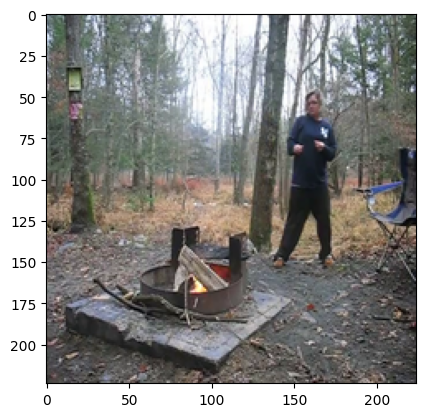

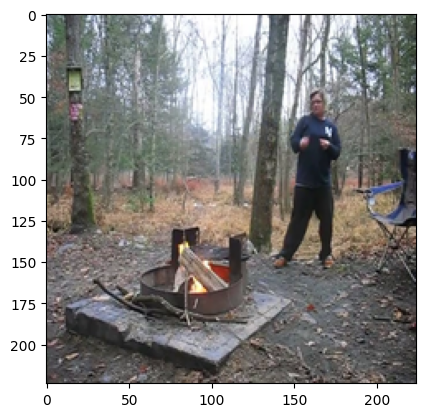

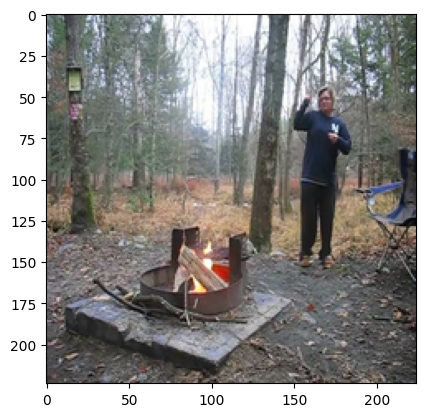

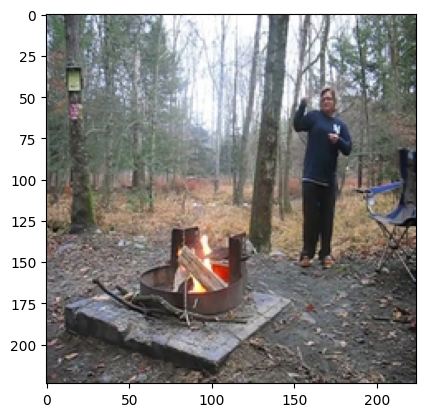

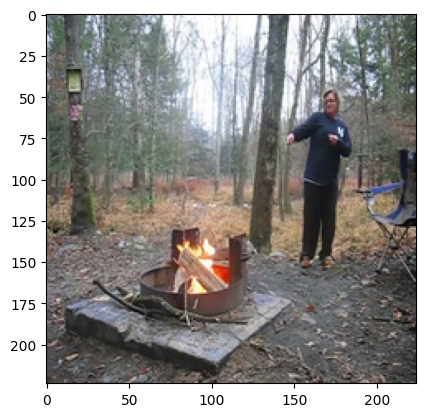

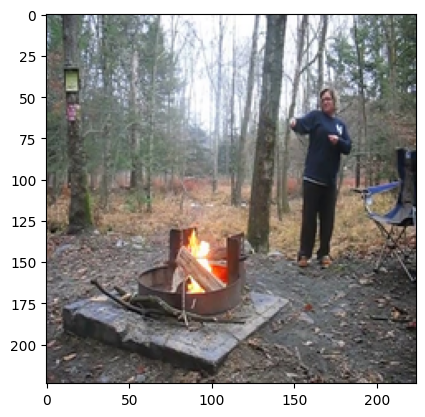

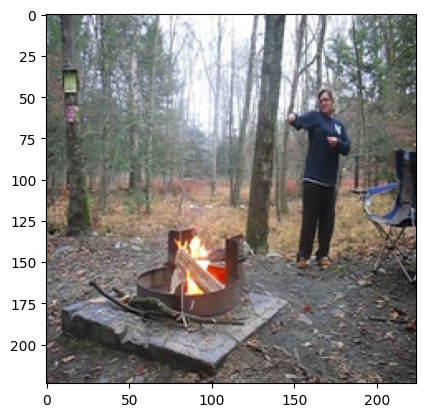

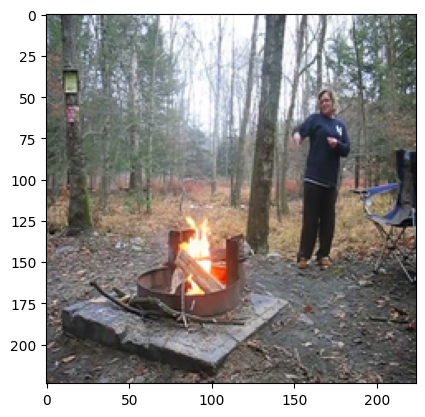

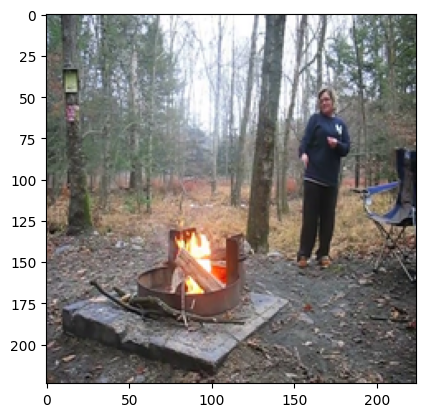

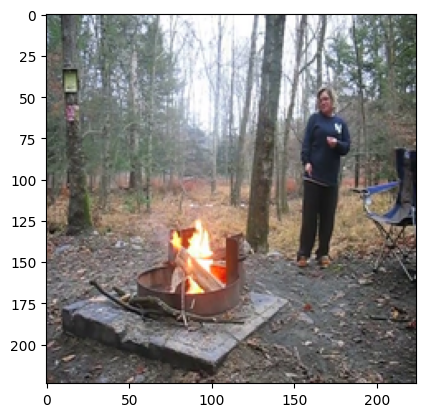

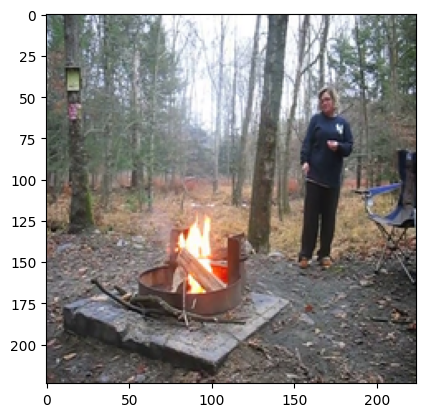

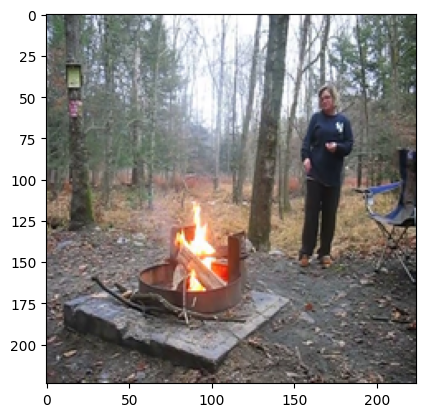

In [16]:
import av
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

fname =        "/data2/local_datasets/ActivityNet/videos/v_7S7THbo8uds.mkv"
fname =        "/data2/local_datasets/ActivityNet/videos/v_vMdSEzQkRTg.mp4"
container = av.open(fname)
video_stream = container.streams.video[0]
total_frames = video_stream.frames
print(total_frames)
if total_frames == 0:
    # Activitynet's mkv and webm files do not provide head information. Therefore, using the estimated value
    for frame in container.decode(video=0):
        total_frames += 1     

container = av.open(fname)
video_stream = container.streams.video[0]
print(f'total frame : {total_frames}')
buffer = []
all_index =[95, 96, 99, 100, 102, 104, 106, 108, 110, 112, 114, 116, 119, 121, 122, 124, 127, 129, 131, 133, 134, 136, 139, 141, 143, 145, 147, 149, 151, 153, 154, 156]
container.seek(4000, stream=video_stream)
current_idx = 0
for frame in container.decode(video=0):
    print(frame.index)
    if frame.index == all_index[current_idx]:
        img = frame.to_image()  # Convert to PIL Image
        img = img.resize((224, 224), Image.ANTIALIAS)
        buffer.append(np.array(img))
        current_idx += 1
        if current_idx == len(all_index):
            break
        
for frame in buffer:
    plt.imshow(frame)
    plt.show()

In [17]:
len(buffer)

12

In [3]:
buffer

[]